# 📊 Stage 5: Evaluation
## Sistem CBR Putusan Pengadilan - Pidana Umum Penggelapan

**Tujuan Notebook ini:**
- Mengevaluasi performa model SVM (Retrieval)
- Mengevaluasi performa prediksi Majority Voting vs Weighted Voting
- Menghitung: Accuracy, Precision, Recall, F1-Score
- Membuat Classification Report dan Confusion Matrix
- Menyimpan hasil evaluasi ke `data/eval/`

**Metrik yang digunakan:**
- **Accuracy** : Berapa % prediksi yang benar
- **Precision** : Dari semua yang diprediksi positif, berapa yang benar?
- **Recall** : Dari semua yang sebenarnya positif, berapa yang berhasil dideteksi?
- **F1-Score** : Rata-rata harmonik Precision dan Recall

---

In [2]:
import sys, os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

from retrieval import retrieve
from reuse import majority_voting, weighted_voting
from evaluation import (
    evaluate_retrieval, evaluate_predictions,
    plot_confusion_matrix, plot_metrics_comparison,
    evaluate_retrieval_similarity
)

print(' Library berhasil diimport!')

 Library berhasil diimport!


## Step 5.1: Load Model dan Data

In [3]:
MODEL_DIR = Path('..') / 'models'
CASES_CSV = Path('..') / 'data' / 'processed' / 'cases.csv'
EVAL_DIR  = Path('..') / 'data' / 'eval'
OUTPUT_DIR = Path('..') / 'outputs'

EVAL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load model
vectorizer   = joblib.load(MODEL_DIR / 'tfidf_vectorizer.pkl')
svm_model    = joblib.load(MODEL_DIR / 'svm_model.pkl')
label_enc    = joblib.load(MODEL_DIR / 'label_encoder.pkl')
tfidf_matrix = joblib.load(MODEL_DIR / 'tfidf_matrix.pkl')

# Load data
df = pd.read_csv(CASES_CSV, encoding='utf-8-sig')
df = df.dropna(subset=['cleaned_text', 'kategori_hukuman'])
df = df[df['kategori_hukuman'] != 'tidak_diketahui'].reset_index(drop=True)

print(f' Model dan data berhasil dimuat!')
print(f'Total kasus valid: {len(df)}')
print(f'\nDistribusi kategori hukuman:')
print(df['kategori_hukuman'].value_counts())

 Model dan data berhasil dimuat!
Total kasus valid: 103

Distribusi kategori hukuman:
kategori_hukuman
ringan    54
berat     49
Name: count, dtype: int64


## Step 5.2: Split Data dan Evaluasi SVM

In [4]:
# Encode label dan split data
le = LabelEncoder()
df['label'] = le.fit_transform(df['kategori_hukuman'])

# Cek apakah bisa stratify (minimal 2 sampel per kelas)
label_counts = df['label'].value_counts()
can_stratify = label_counts.min() >= 2

df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['label'] if can_stratify else None
)

# Transform test data
X_test = vectorizer.transform(df_test['cleaned_text'])
y_test = df_test['label'].values

print(f'Training set : {len(df_train)} kasus')
print(f'Test set     : {len(df_test)} kasus')

# Evaluasi SVM
print('\n' + '='*50)
print('EVALUASI MODEL SVM (RETRIEVAL)')
print('='*50)
retrieval_metrics = evaluate_retrieval(
    svm_model, X_test, y_test, le,
    output_dir=str(EVAL_DIR)
)

print(f'\nClassification Report:')
print(retrieval_metrics['report'])

2026-06-19 22:06:15,646 - INFO - Mengevaluasi model retrieval (SVM)...
2026-06-19 22:06:15,662 - INFO - Accuracy  : 0.6667
2026-06-19 22:06:15,662 - INFO - Precision : 0.6769
2026-06-19 22:06:15,663 - INFO - Recall    : 0.6667
2026-06-19 22:06:15,663 - INFO - F1-Score  : 0.6573
2026-06-19 22:06:15,668 - INFO - 
Classification Report:
              precision    recall  f1-score   support

       berat       0.71      0.50      0.59        10
      ringan       0.64      0.82      0.72        11

    accuracy                           0.67        21
   macro avg       0.68      0.66      0.65        21
weighted avg       0.68      0.67      0.66        21



Training set : 82 kasus
Test set     : 21 kasus

EVALUASI MODEL SVM (RETRIEVAL)


2026-06-19 22:06:15,671 - INFO - Metrik tersimpan: ..\data\eval/retrieval_metrics.csv



Classification Report:
              precision    recall  f1-score   support

       berat       0.71      0.50      0.59        10
      ringan       0.64      0.82      0.72        11

    accuracy                           0.67        21
   macro avg       0.68      0.66      0.65        21
weighted avg       0.68      0.67      0.66        21



## Step 5.3: Confusion Matrix SVM

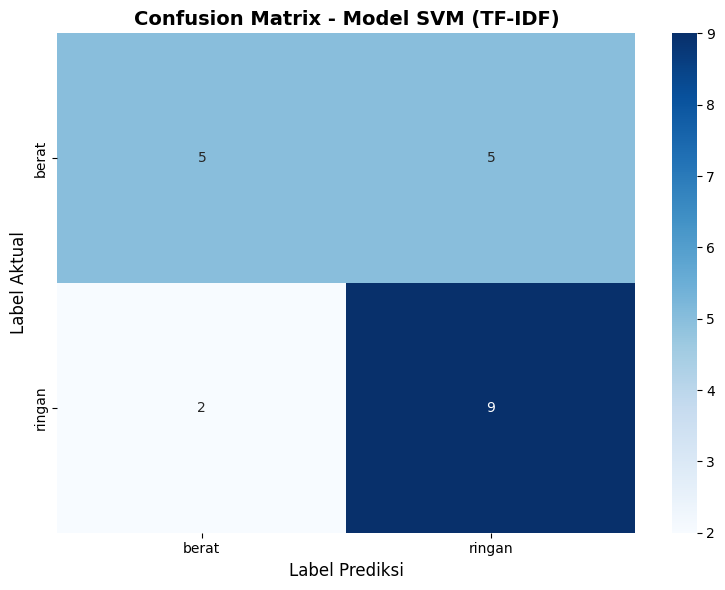

2026-06-19 22:06:15,905 - INFO - Confusion matrix tersimpan: ..\outputs\confusion_matrix_svm.png


 Confusion matrix SVM tersimpan


In [5]:
# Plot confusion matrix SVM
plot_confusion_matrix(
    retrieval_metrics['y_test_labels'],
    retrieval_metrics['y_pred_labels'],
    title='Confusion Matrix - Model SVM (TF-IDF)',
    output_path=str(OUTPUT_DIR / 'confusion_matrix_svm.png')
)
print(' Confusion matrix SVM tersimpan')

## Step 5.4: Evaluasi Metode Prediksi (Voting)

In [6]:
# Jalankan prediksi pada semua data test menggunakan kedua metode voting
print('Menjalankan prediksi pada data test...')

y_true = []
y_pred_majority = []
y_pred_weighted = []

# Rekonstruksi TF-IDF matrix untuk semua data
tfidf_all = vectorizer.transform(df['cleaned_text'])

for idx, row in df_test.iterrows():
    query = str(row['cleaned_text'])
    true_label = row['kategori_hukuman']
    
    # Retrieve top-5 kasus mirip
    top_cases = retrieve(query, vectorizer, tfidf_all, df, top_k=5)
    
    # Prediksi dengan kedua metode
    pred_maj, _ = majority_voting(top_cases)
    pred_wgt, _ = weighted_voting(top_cases)
    
    y_true.append(true_label)
    y_pred_majority.append(pred_maj)
    y_pred_weighted.append(pred_wgt)

print(f' Prediksi selesai untuk {len(y_true)} kasus test')

Menjalankan prediksi pada data test...


2026-06-19 22:06:16,502 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:16,503 - INFO - Majority Voting: {'ringan': 5} -> Prediksi: ringan
2026-06-19 22:06:16,504 - INFO - Weighted Voting: {'ringan': 2.2582} -> Prediksi: ringan
2026-06-19 22:06:16,511 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:16,512 - INFO - Majority Voting: {'ringan': 2, 'berat': 3} -> Prediksi: berat
2026-06-19 22:06:16,513 - INFO - Weighted Voting: {'ringan': 1.398, 'berat': 1.0803} -> Prediksi: ringan
2026-06-19 22:06:16,521 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:16,522 - INFO - Majority Voting: {'berat': 4, 'ringan': 1} -> Prediksi: berat
2026-06-19 22:06:16,523 - INFO - Weighted Voting: {'berat': 2.0721, 'ringan': 0.3565} -> Prediksi: berat
2026-06-19 22:06:16,536 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:16,537 - INFO - Majority Voting: {'ringan': 2, 'berat': 3} -> Prediksi: berat
2026-06-19 22:06:16,537 - INFO - Weighted Voting: {'ringan': 1.3423, 'berat'

 Prediksi selesai untuk 21 kasus test


In [7]:
# Evaluasi dan bandingkan kedua metode
print('='*50)
print('EVALUASI METODE PREDIKSI')
print('='*50)
pred_metrics = evaluate_predictions(
    y_true, y_pred_majority, y_pred_weighted,
    output_dir=str(EVAL_DIR)
)

# Tampilkan tabel perbandingan
print('\nTabel Perbandingan Metrik:')
comparison_df = pd.DataFrame([pred_metrics['majority'], pred_metrics['weighted']])
print(comparison_df.to_string(index=False))

2026-06-19 22:06:16,760 - INFO - Membandingkan metode prediksi...
2026-06-19 22:06:16,766 - INFO - 
Majority Voting: Acc=0.7619 | P=0.7632 | R=0.7619 | F1=0.7608
2026-06-19 22:06:16,774 - INFO - 
Weighted Voting: Acc=1.0000 | P=1.0000 | R=1.0000 | F1=1.0000
2026-06-19 22:06:16,776 - INFO - Metrik prediksi tersimpan: ..\data\eval/prediction_metrics.csv


EVALUASI METODE PREDIKSI

Tabel Perbandingan Metrik:
         method  accuracy  precision  recall  f1_score
Majority Voting    0.7619     0.7632  0.7619    0.7608
Weighted Voting    1.0000     1.0000  1.0000    1.0000


## Step 5.5: Confusion Matrix - Kedua Metode

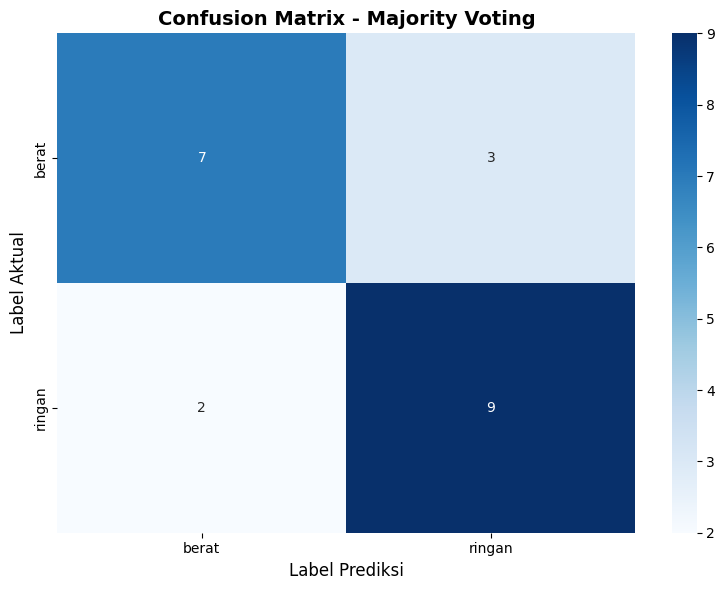

2026-06-19 22:06:16,948 - INFO - Confusion matrix tersimpan: ..\outputs\confusion_matrix_majority.png


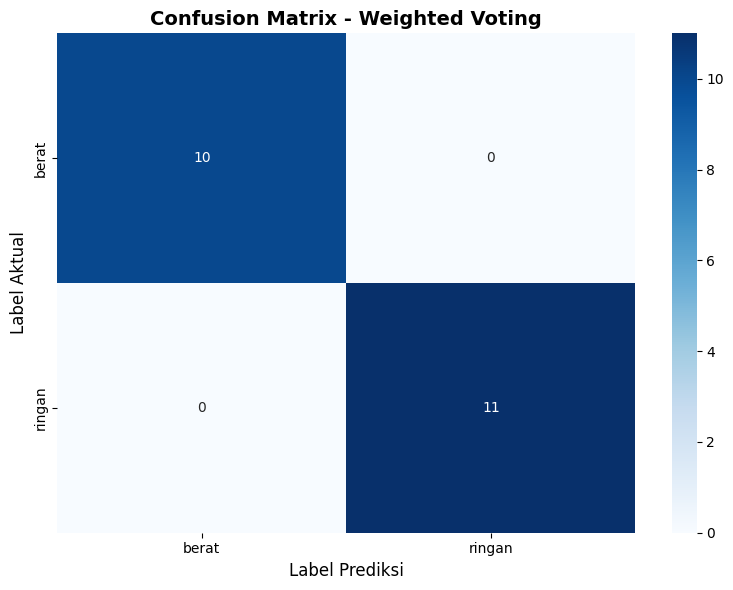

2026-06-19 22:06:17,088 - INFO - Confusion matrix tersimpan: ..\outputs\confusion_matrix_weighted.png


 Confusion matrix kedua metode tersimpan


In [8]:
# Confusion Matrix Majority Voting
plot_confusion_matrix(
    y_true, y_pred_majority,
    title='Confusion Matrix - Majority Voting',
    output_path=str(OUTPUT_DIR / 'confusion_matrix_majority.png')
)

# Confusion Matrix Weighted Voting
plot_confusion_matrix(
    y_true, y_pred_weighted,
    title='Confusion Matrix - Weighted Voting',
    output_path=str(OUTPUT_DIR / 'confusion_matrix_weighted.png')
)

print(' Confusion matrix kedua metode tersimpan')

## Step 5.6: Visualisasi Perbandingan Metrik

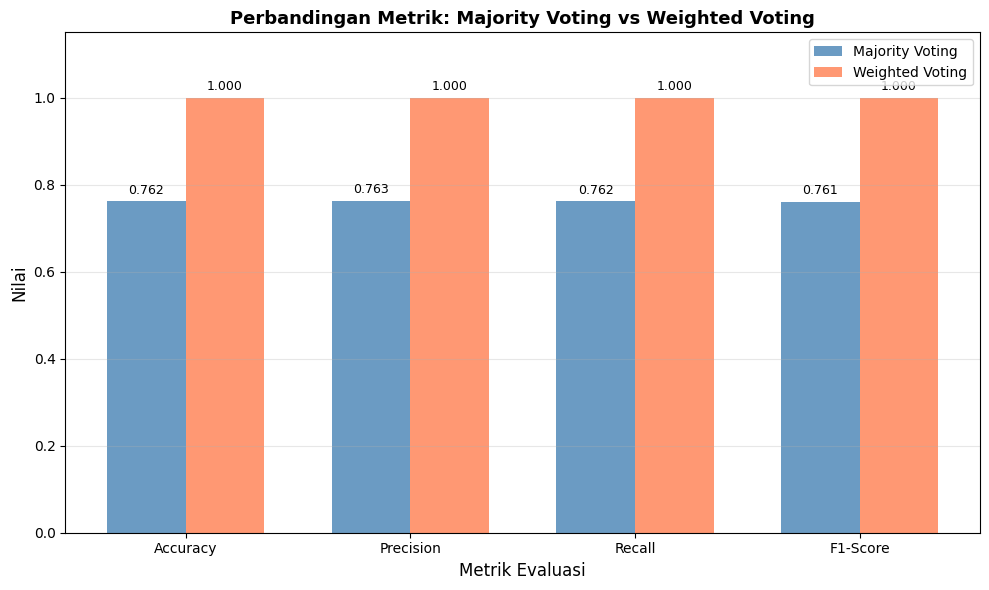

2026-06-19 22:06:17,257 - INFO - Grafik perbandingan tersimpan: ..\outputs\metrics_comparison.png


 Grafik perbandingan tersimpan


In [9]:
# Bar chart perbandingan semua metrik
plot_metrics_comparison(
    pred_metrics,
    output_path=str(OUTPUT_DIR / 'metrics_comparison.png')
)
print(' Grafik perbandingan tersimpan')

## Step 5.7: Precision@K - Evaluasi Retrieval

In [10]:
# Hitung Precision@K untuk berbagai nilai K
print('Menghitung Precision@K...')

k_values = [1, 3, 5]
precision_k_results = {}

for k in k_values:
    prec_k = evaluate_retrieval_similarity(
        df_test, vectorizer, tfidf_all, df, top_k=k
    )
    precision_k_results[f'P@{k}'] = round(prec_k, 4)
    print(f'  Precision@{k} = {prec_k:.4f}')

print('\n Evaluasi Precision@K selesai')

2026-06-19 22:06:17,263 - INFO - Menghitung Precision@1...
2026-06-19 22:06:17,271 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,279 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,288 - INFO - Ditemukan 1 kasus paling mirip


Menghitung Precision@K...


2026-06-19 22:06:17,302 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,308 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,318 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,324 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,332 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,359 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,377 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,388 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,407 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,427 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,433 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,451 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,456 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,461 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,466 - INFO - Ditemukan 1 kasus paling mirip
2026-06-19 22:06:17,475 - INFO - Ditemuk

  Precision@1 = 0.5714


2026-06-19 22:06:17,701 - INFO - Ditemukan 3 kasus paling mirip
2026-06-19 22:06:17,710 - INFO - Ditemukan 3 kasus paling mirip
2026-06-19 22:06:17,711 - INFO - Rata-rata Precision@3: 0.6032
2026-06-19 22:06:17,712 - INFO - Menghitung Precision@5...
2026-06-19 22:06:17,722 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,730 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,740 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,753 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,759 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,770 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,775 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,783 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,808 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,826 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,835 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,855 - INFO - Ditemukan 5 k

  Precision@3 = 0.6032


2026-06-19 22:06:17,918 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,927 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,935 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,944 - INFO - Ditemukan 5 kasus paling mirip
2026-06-19 22:06:17,945 - INFO - Rata-rata Precision@5: 0.6000


  Precision@5 = 0.6000

 Evaluasi Precision@K selesai


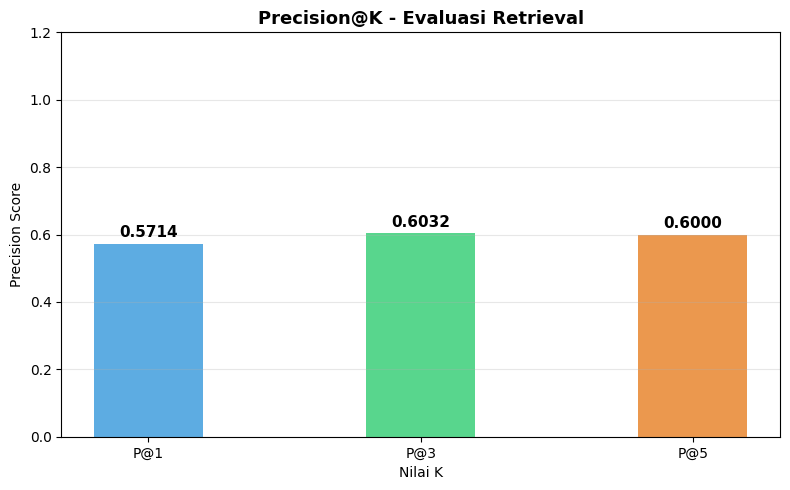

 Visualisasi Precision@K tersimpan


In [11]:
# Visualisasi Precision@K
plt.figure(figsize=(8, 5))
k_names = list(precision_k_results.keys())
k_scores = list(precision_k_results.values())
bars = plt.bar(k_names, k_scores, color=['#3498db', '#2ecc71', '#e67e22'], alpha=0.8, width=0.4)
plt.title('Precision@K - Evaluasi Retrieval', fontsize=13, fontweight='bold')
plt.xlabel('Nilai K')
plt.ylabel('Precision Score')
plt.ylim(0, 1.2)
for bar, score in zip(bars, k_scores):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{score:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'precision_at_k.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Visualisasi Precision@K tersimpan')

## Step 5.8: Ringkasan Semua Metrik

In [12]:
# =====================================================
# RINGKASAN FINAL SEMUA EVALUASI
# =====================================================
print('=' * 60)
print('📊 RINGKASAN EVALUASI SISTEM CBR')
print('   Domain: Pidana Umum Penggelapan')
print('=' * 60)

print('\n1️⃣  MODEL RETRIEVAL (SVM + TF-IDF):')
print(f'   Accuracy  : {retrieval_metrics["accuracy"]:.4f} ({retrieval_metrics["accuracy"]*100:.1f}%)')
print(f'   Precision : {retrieval_metrics["precision"]:.4f}')
print(f'   Recall    : {retrieval_metrics["recall"]:.4f}')
print(f'   F1-Score  : {retrieval_metrics["f1_score"]:.4f}')

print('\n2️⃣  PREDIKSI - MAJORITY VOTING:')
print(f'   Accuracy  : {pred_metrics["majority"]["accuracy"]:.4f} ({pred_metrics["majority"]["accuracy"]*100:.1f}%)')
print(f'   Precision : {pred_metrics["majority"]["precision"]:.4f}')
print(f'   Recall    : {pred_metrics["majority"]["recall"]:.4f}')
print(f'   F1-Score  : {pred_metrics["majority"]["f1_score"]:.4f}')

print('\n3️⃣  PREDIKSI - WEIGHTED VOTING:')
print(f'   Accuracy  : {pred_metrics["weighted"]["accuracy"]:.4f} ({pred_metrics["weighted"]["accuracy"]*100:.1f}%)')
print(f'   Precision : {pred_metrics["weighted"]["precision"]:.4f}')
print(f'   Recall    : {pred_metrics["weighted"]["recall"]:.4f}')
print(f'   F1-Score  : {pred_metrics["weighted"]["f1_score"]:.4f}')

print('\n4️⃣  PRECISION@K (Retrieval Quality):')
for k, v in precision_k_results.items():
    print(f'   {k} : {v:.4f}')

print('\n' + '=' * 60)
print('📁 File hasil evaluasi:')
print('   data/eval/retrieval_metrics.csv')
print('   data/eval/prediction_metrics.csv')
print('   outputs/confusion_matrix_*.png')
print('   outputs/metrics_comparison.png')
print('   outputs/precision_at_k.png')
print('=' * 60)

📊 RINGKASAN EVALUASI SISTEM CBR
   Domain: Pidana Umum Penggelapan

1️⃣  MODEL RETRIEVAL (SVM + TF-IDF):
   Accuracy  : 0.6667 (66.7%)
   Precision : 0.6769
   Recall    : 0.6667
   F1-Score  : 0.6573

2️⃣  PREDIKSI - MAJORITY VOTING:
   Accuracy  : 0.7619 (76.2%)
   Precision : 0.7632
   Recall    : 0.7619
   F1-Score  : 0.7608

3️⃣  PREDIKSI - WEIGHTED VOTING:
   Accuracy  : 1.0000 (100.0%)
   Precision : 1.0000
   Recall    : 1.0000
   F1-Score  : 1.0000

4️⃣  PRECISION@K (Retrieval Quality):
   P@1 : 0.5714
   P@3 : 0.6032
   P@5 : 0.6000

📁 File hasil evaluasi:
   data/eval/retrieval_metrics.csv
   data/eval/prediction_metrics.csv
   outputs/confusion_matrix_*.png
   outputs/metrics_comparison.png
   outputs/precision_at_k.png
